# Fragmented criticality: reusable numerical method

This notebook implements the multitype Poisson branching-process calculation used in *Fragmented criticality of infectious disease epidemics*. Supply a non-negative square matrix $C$ and define $R=rC$.

**Matrix convention.** $R_{ji}$ is the expected number of infections in stratum $j$ caused by one infected individual in stratum $i$. Consequently, the epidemic-probability equation contains $C^T p$. This convention and every transpose below are intentional.

For direct comparison across applications, normalize $C$ to spectral radius one. The functions do not silently renormalize the input; `normalize_C` is provided explicitly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import root
from scipy.special import lambertw

np.set_printoptions(precision=6, suppress=True)

## Core branching-process quantities

For Poisson offspring, the probability $p_i$ that an introduction in stratum $i$ generates a major epidemic is the maximal real solution of

$$p_i=1-\exp\left[-r\sum_j C_{ji}p_j\right].$$

The iteration below starts at one, selecting that physical solution. Below threshold it converges to zero.

In [2]:
def validate_C(C):
    C = np.asarray(C, dtype=float)
    if C.ndim != 2 or C.shape[0] != C.shape[1]:
        raise ValueError("C must be a square matrix")
    if not np.all(np.isfinite(C)) or np.any(C < 0):
        raise ValueError("C must contain finite, non-negative entries")
    return C


def spectral_radius(A):
    return float(np.max(np.abs(np.linalg.eigvals(np.asarray(A)))))


def normalize_C(C):
    C = validate_C(C)
    rho = spectral_radius(C)
    if rho == 0:
        raise ValueError("C must have positive spectral radius")
    return C / rho


def epidemic_probability(C, r, tol=1e-12, max_iter=100_000):
    C = validate_C(C)
    if not np.isreal(r) or float(np.real(r)) < 0:
        raise ValueError("epidemic_probability expects a non-negative real r")
    r = float(np.real(r))
    p = np.ones(C.shape[0])
    for _ in range(max_iter):
        p_next = 1.0 - np.exp(-r * (C.T @ p))
        if np.max(np.abs(p_next - p)) < tol:
            return np.clip(p_next, 0.0, 1.0)
        p = p_next
    raise RuntimeError("epidemic-probability iteration did not converge")


def extinction_conditioned_operator(C, r, p=None):
    C = validate_C(C)
    if p is None:
        p = epidemic_probability(C, r)
    p = np.asarray(p)
    if p.shape != (C.shape[0],):
        raise ValueError("p must have one entry per stratum")
    # Paper convention: R_hat_ij = (1-p_i) R_ij.
    return np.diag(1.0 - p) @ (r * C)


def expected_minor_outbreak_size(C, r, p=None, condition_limit=1e14):
    R_hat = extinction_conditioned_operator(C, r, p)
    L = np.eye(R_hat.shape[0], dtype=R_hat.dtype) - R_hat.T
    if np.linalg.cond(L) > condition_limit:
        return np.full(R_hat.shape[0], np.inf, dtype=L.dtype)
    return np.linalg.solve(L, np.ones(R_hat.shape[0], dtype=L.dtype))

## Complex critical points and critical modes

Complex critical points satisfy the analytically continued epidemic-probability equation together with

$$\det L=0,\qquad L=I-\hat R^T.$$

The solver uses the decoupled thresholds $1/C_{ii}$ as numerical seeds, refines the full complex system with a Newton-type solver, retains roots only when the residual is below `residual_tol`, requires recovery of the complex conjugate, and filters out points for which the unit eigenvalue is not the spectral-radius-setting mode. These are the numerical filters described in the paper. Because roots occur in conjugate pairs, the returned table keeps only $\operatorname{Im}r_c\geq0$.

In [3]:
def _complex_equations(x, C):
    n = C.shape[0]
    p = x[:n] + 1j * x[n:2*n]
    r_value = x[-2] + 1j * x[-1]
    with np.errstate(over="ignore", invalid="ignore"):
        F = p - 1.0 + np.exp(-r_value * (C.T @ p))
    R_hat = np.diag(1.0 - p) @ (r_value * C)
    L = np.eye(n, dtype=complex) - R_hat.T
    equations = np.r_[F, np.linalg.det(L)]
    return np.r_[equations.real, equations.imag]


def _decoupled_seed(C, r_value, focal):
    diagonal = np.diag(C)
    p = np.zeros(C.shape[0], dtype=complex)
    for j, cjj in enumerate(diagonal):
        if cjj == 0 or j == focal:
            continue
        a = r_value * cjj
        p[j] = 1.0 + lambertw(-a * np.exp(-a), 0) / a
    return p


def _pack(p, r_value):
    return np.r_[p.real, p.imag, r_value.real, r_value.imag]


def _unpack(x, n):
    return x[:n] + 1j*x[n:2*n], x[-2] + 1j*x[-1]


def critical_mode(C, r_c, p_c, zero_tol=1e-6):
    R_hat = extinction_conditioned_operator(C, r_c, p_c)
    L = np.eye(C.shape[0], dtype=complex) - R_hat.T
    values, vectors = eig(L)
    k = int(np.argmin(np.abs(values)))
    if abs(values[k]) > zero_tol:
        raise ValueError("no near-null mode at this candidate")
    w = vectors[:, k]
    localization = np.abs(w) / np.sqrt(np.sum(np.abs(w)**2))
    return w, localization, values[k]


def complex_critical_points(
    C, residual_tol=1e-6, conjugate_tol=1e-4,
    stability_tol=1e-5, duplicate_tol=1e-4
):
    C = validate_C(C)
    n = C.shape[0]
    raw = []
    # Several imaginary offsets make the continuation robust while retaining
    # the paper's decoupled-threshold initialization.
    offsets = (0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4)
    for focal, cii in enumerate(np.diag(C)):
        if cii <= 0:
            continue
        r0 = 1.0 / cii
        for sign in (-1.0, 1.0):
            for fraction in offsets:
                r_seed = r0 * (1.0 + 1j * sign * fraction)
                p_seed = _decoupled_seed(C, r_seed, focal)
                solution = root(_complex_equations, _pack(p_seed, r_seed), args=(C,), method="lm")
                p_c, r_c = _unpack(solution.x, n)
                residual = np.max(np.abs(_complex_equations(solution.x, C)))
                if solution.success and residual < residual_tol and r_c.real > 0:
                    R_hat = extinction_conditioned_operator(C, r_c, p_c)
                    eigenvalues = np.linalg.eigvals(R_hat)
                    if abs(np.max(np.abs(eigenvalues)) - 1.0) <= stability_tol:
                        raw.append((r_c, p_c, residual))

    unique = []
    for candidate in sorted(raw, key=lambda item: (item[0].real, item[0].imag)):
        if not any(abs(candidate[0] - kept[0]) < duplicate_tol for kept in unique):
            unique.append(candidate)

    retained = []
    for r_c, p_c, residual in unique:
        solved_r_c = r_c
        if abs(solved_r_c.imag) < conjugate_tol:
            r_c = complex(solved_r_c.real, 0.0)
        elif not any(abs(other[0] - np.conj(solved_r_c)) < conjugate_tol for other in unique):
            continue
        if solved_r_c.imag < -conjugate_tol:
            continue
        if any(abs(r_c - kept["r_c"]) < duplicate_tol for kept in retained):
            continue
        # Compute the null mode at the solved root. Snapping a near-real root
        # to the real axis before this check can create an artificial residual.
        w, localization, null_eigenvalue = critical_mode(C, solved_r_c, p_c, zero_tol=residual_tol*10)
        retained.append({
            "r_c": r_c, "p_c": p_c, "residual": residual,
            "mode": w, "localization": localization,
            "null_eigenvalue": null_eigenvalue,
        })
    return retained

## Fully reproducible Figure 1 two-stratum example

No empirical data are required. Replace `C` below with another non-negative square matrix to apply the same workflow. This example already has spectral radius one.

In [4]:
C = np.array([
    [0.5,   0.0],
    [0.006, 1.0],
])
validate_C(C)
print("C =\n", C)
print("spectral radius:", spectral_radius(C))
print("global epidemic threshold 1/rho(C):", 1.0 / spectral_radius(C))

C =
 [[0.5   0.   ]
 [0.006 1.   ]]
spectral radius: 1.0
global epidemic threshold 1/rho(C): 1.0


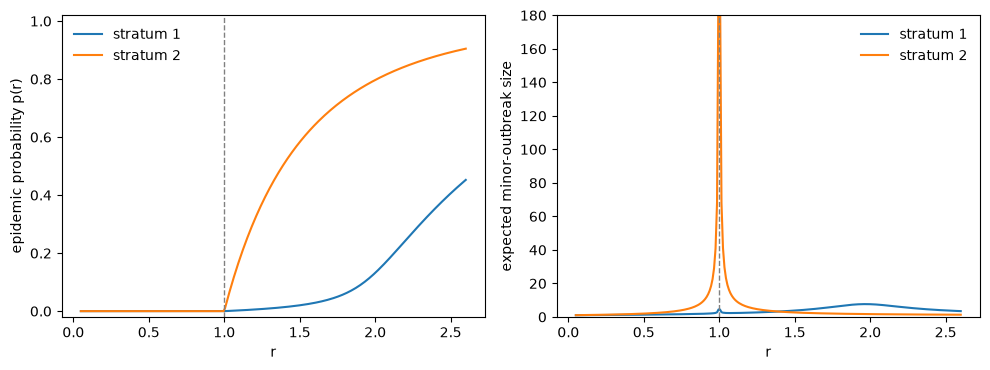

In [5]:
r_values = np.linspace(0.05, 2.6, 260)
p_values = np.vstack([epidemic_probability(C, r) for r in r_values])
minor_sizes = np.vstack([expected_minor_outbreak_size(C, r) for r in r_values])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for i in range(C.shape[0]):
    axes[0].plot(r_values, p_values[:, i], label=f"stratum {i+1}")
    axes[1].plot(r_values, minor_sizes[:, i].real, label=f"stratum {i+1}")
axes[0].set(xlabel="r", ylabel="epidemic probability p(r)", ylim=(-0.02, 1.02))
axes[1].set(xlabel="r", ylabel="expected minor-outbreak size", ylim=(0, 180))
for ax in axes:
    ax.axvline(1.0, color="0.5", linestyle="--", linewidth=1)
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [6]:
critical_points = complex_critical_points(C)
assert critical_points, "No critical points were recovered"
for point in critical_points:
    print(f"r_c = {point['r_c']:.8g}; residual = {point['residual']:.2e}")
    print("  localization =", point["localization"])

# Reproducibility checks: the positive real threshold and the non-real point
# associated with the weakly coupled first stratum must both be present.
assert any(abs(point["r_c"] - 1.0) < 1e-4 for point in critical_points)
assert any(point["r_c"].real > 1.5 and point["r_c"].imag > 1e-4 for point in critical_points)

r_c = 1+0j; residual = 7.23e-22
  localization = [0.011999 0.999928]
r_c = 1.9555954+0.27119953j; residual = 6.29e-17
  localization = [1. 0.]


### Applying the method to another matrix

1. Set `C_user = np.asarray(...)` using the same row/column convention.
2. Optionally call `C_user = normalize_C(C_user)` so that the global threshold is `r=1`.
3. Evaluate `epidemic_probability`, `extinction_conditioned_operator`, and `expected_minor_outbreak_size` along the real `r` axis.
4. Call `complex_critical_points(C_user)` and inspect each returned `r_c` and `localization` vector.

For large empirical matrices, tune the seed offsets and tolerances only after checking convergence and conjugate recovery.